In [4]:
import numpy as numpy
import pandas as pd
from sklearn.datasets import make_classification

In [5]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)


In [6]:
df=pd.DataFrame(X, columns=['col1','col2','col3','col4','col5'])
df['target']=y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.220226,0.625966,-2.607402,1.599189,-1.410279,1
1,1.635355,-0.349302,-2.506553,1.949549,0.517158,0
2,2.341625,-0.866373,-1.915818,0.425391,0.126706,1
3,1.461767,-1.811146,-0.104349,-1.823674,-0.307989,1
4,1.603366,-1.960042,-0.334415,-4.504246,0.756687,1


In [7]:
def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]), replace=True)

In [8]:
import random
def sample_features(df, percent):
    cols= random.sample(df.columns.tolist()[:-1], int(percent*df.shape[1]))
    return df[cols]

In [ ]:
def combined_sampling(df, row_percent, col_percent):
    return sample_rows(sample_features(df, col_percent), row_percent)

In [33]:
df1=sample_rows(df, 0.2)

In [34]:
df2=sample_rows(df, 0.2)

In [35]:
df3=sample_rows(df, 0.2)

In [36]:
from sklearn.tree import DecisionTreeClassifier
cf1=DecisionTreeClassifier()
cf2=DecisionTreeClassifier()
cf3=DecisionTreeClassifier()    

In [37]:
print(df2.shape)

(20, 6)


In [42]:
cf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
cf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
cf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

[Text(0.4, 0.8333333333333334, 'x[4] <= 0.075\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= -1.93\ngini = 0.165\nsamples = 11\nvalue = [10, 1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]')]

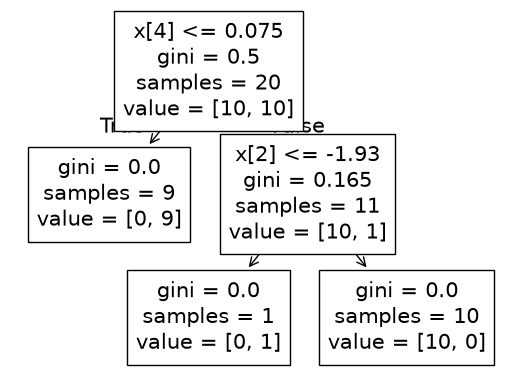

In [43]:
from sklearn.tree import plot_tree
plot_tree(cf1)

In [44]:
import numpy as np
cf1.predict(np.array([[0.551380, -1.876185, -1.8077618, 0.5, 0.5]]))

c:\Users\Jaswinder Singh\OneDrive\Deep-learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [45]:
cf2.predict(np.array([[0.551380, -1.876185, -1.8077618, 0.5, 0.5]]))

c:\Users\Jaswinder Singh\OneDrive\Deep-learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [46]:
cf3.predict(np.array([[0.551380, -1.876185, -1.8077618, 0.5, 0.5]]))

c:\Users\Jaswinder Singh\OneDrive\Deep-learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])